<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/28_stl_Shewhart_Outlier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# ----------------------------
# 1. 강의용 원본 데이터 (월별 날짜와 수치; 입력값 변경 없음)
# ----------------------------
raw_data = """
Date,Total
1986-01-01,9034
1986-02-01,9596
1986-03-01,10558
1986-04-01,9002
1986-05-01,9239
1986-06-01,8951
1986-07-01,9668
1986-08-01,10188
1986-09-01,9896
1986-10-01,10649
1986-11-01,8917
1986-12-01,8196
1987-01-01,10768
1987-02-01,12220
1987-03-01,14463
1987-04-01,12944
1987-05-01,11001
1987-06-01,11000
1987-07-01,11876
1987-08-01,13021
1987-09-01,13494
1987-10-01,14041
1987-11-01,11312
1987-12-01,10362
1988-01-01,12533
1988-02-01,14343
1988-03-01,14676
1988-04-01,12253
1988-05-01,11840
1988-06-01,12018
1988-07-01,11819
1988-08-01,12453
1988-09-01,12309
1988-10-01,13005
1988-11-01,11815
1988-12-01,10496
1989-01-01,13996
1989-02-01,15158
1989-03-01,15587
1989-04-01,14615
1989-05-01,14792
1989-06-01,14373
1989-07-01,14573
1989-08-01,14385
1989-09-01,15607
1989-10-01,15978
1989-11-01,14436
1989-12-01,12794
1990-01-01,15771
1990-02-01,16476
1990-03-01,16420
1990-04-01,15444
1990-05-01,16118
1990-06-01,15158
1990-07-01,15214
1990-08-01,16257
1990-09-01,15287
1990-10-01,15212
1990-11-01,13488
1990-12-01,12300
1991-01-01,15794
1991-02-01,17113
1991-03-01,17536
1991-04-01,15914
1991-05-01,16716
1991-06-01,15983
1991-07-01,16878
1991-08-01,17893
1991-09-01,16697
1991-10-01,18546
1991-11-01,15486
1991-12-01,15253
1992-01-01,18698
1992-02-01,	21100
1992-03-01,	22425
1992-04-01,	19923
1992-05-01,19454
1992-06-01,	18874
1992-07-01,	19676
1992-08-01,	19559
1992-09-01,	19500
1992-10-01,	19615
1992-11-01,	16814
1992-12-01,	15698
1993-01-01,	20273
1993-02-01,	20774
1993-03-01,	21309
1993-04-01,	19377
1993-05-01,	19211
1993-06-01,	19103
1993-07-01,	20086
1993-08-01,	19758
1993-09-01,	19162
1993-10-01,	19371
1993-11-01,	17709
1993-12-01,	17342
1994-01-01,	18772
1994-02-01,	19363
1994-03-01,	20001
1994-04-01,17112
1994-05-01,	18027
1994-06-01,	17173
1994-07-01,	18024
1994-08-01,	18983
1994-09-01,	17983
1994-10-01,	19151
1994-11-01,	16427
1994-12-01,	15461
1995-01-01,	19191
1995-02-01,	20008
1995-03-01,	21702
1995-04-01,	18649
1995-05-01,	19169
1995-06-01,	18631
1995-07-01,	18157
1995-08-01,	20187
1995-09-01,	18660
1995-10-01,	19920
1995-11-01,	16680
1995-12-01,	16018
1996-01-01,	20322
1996-02-01,	20613
1996-03-01,	22704
1996-04-01,	20276
1996-05-01,	20669
1996-06-01,	18074
1996-07-01,	18719
1996-08-01,	20217
1996-09-01,	19642
1996-10-01,	20842
1996-11-01,	18204
1996-12-01,	16898
1997-01-01,	20746
1997-02-01,	23058
1997-03-01,	24624
1997-04-01,	22154
1997-05-01,	22444
1997-06-01,	21471
1997-07-01,	21866
1997-08-01,	22548
1997-09-01,	21518
1997-10-01,	23408
1997-11-01,	19645
1997-12-01,	18278
1998-01-01,	23576
1998-02-01,	26650
1998-03-01,	26207
1998-04-01,	23195
1998-05-01,	22960
1998-06-01,	23002
1998-07-01,	22973
1998-08-01,	24089
1998-09-01,	22805
1998-10-01,	23241
1998-11-01,	21581
1998-12-01,	21119
1999-01-01,	23107
1999-02-01,	25780
1999-03-01,	28544
1999-04-01,	23488
1999-05-01,	23964
1999-06-01,	23720
1999-07-01,	25069
1999-08-01,	24618
1999-09-01,	24430
1999-10-01,	25229
1999-11-01,	22344
1999-12-01,	22372
2000-01-01,	25412
2000-02-01,	25354
2000-03-01,	29161
2000-04-01,	24924
2000-05-01,	24763
2000-06-01,	25342
2000-07-01,	24911
2000-08-01,	25847
2000-09-01,	23743
2000-10-01,	25036
2000-11-01,	21911
2000-12-01,	20752
2001-01-01,	24507
2001-02-01,	25968
2001-03-01,	28752
2001-04-01,	25167
2001-05-01,	24728
2001-06-01,	23690
2001-07-01,	24816
2001-08-01,	26004
2001-09-01,	24210
2001-10-01,	25083
2001-11-01,	21807
2001-12-01,	21635
2002-01-01,	27173
2002-02-01,	29308
2002-03-01,	28645
2002-04-01,	25023
2002-05-01,	27261
2002-06-01,	24670
2002-07-01,	26441
2002-08-01,	27961
2002-09-01,	26498
2002-10-01,	27800
2002-11-01,	23939
2002-12-01,	22930
2003-01-01,	27584
2003-02-01,	27586
2003-03-01,	30485
2003-04-01,	26135
2003-05-01,	27370
2003-06-01,	25487
2003-07-01,	26427
2003-08-01,	27672
2003-09-01,	26853
2003-10-01,	27875
2003-11-01,	23416
2003-12-01,	22482
2004-01-01,	27140
2004-02-01,	28526
2004-03-01,	28845
2004-04-01,	25033
2004-05-01,	24764
2004-06-01,	24896
2004-07-01,	24623
2004-08-01,	26538
2004-09-01,	24674
2004-10-01,	25863
2004-11-01,	23156
2004-12-01,	22721
2005-01-01,	26204
2005-02-01,	26526
2005-03-01,	27473
2005-04-01,	24536
2005-05-01,	25764
2005-06-01,	25154
2005-07-01,	23729
2005-08-01,	25336
2005-09-01,	24649
2005-10-01,	25904
2005-11-01,	22868
2005-12-01,	21825
2006-01-01,	26955
2006-02-01,	27349
2006-03-01,	29367
2006-04-01,	24071
2006-05-01,	23173
2006-06-01,	21740
2006-07-01,	22056
2006-08-01,	23923
2006-09-01,	22189
2006-10-01,	22458
2006-11-01,	19476
2006-12-01,	21056
2007-01-01,	22842
2007-02-01,	22943
2007-03-01,	23445
2007-04-01,	19176
2007-05-01,	22058
2007-06-01,	19451
2007-07-01,	20378
2007-08-01,	21778
2007-09-01,	20431
2007-10-01,	22486
2007-11-01,	18889
2007-12-01,	18574
2008-01-01,	24658
2008-02-01,	24997
2008-03-01,	23987
2008-04-01,	21199
2008-05-01,	21205
2008-06-01,	21553
2008-07-01,	21166
2008-08-01, 20720
2008-09-01,	18067
2008-10-01,	21121
2008-11-01,	16617
2008-12-01,	15917
2009-01-01,	19262
2009-02-01,	20658
2009-03-01,	22660
2009-04-01,	20147
2009-05-01,	18818
2009-06-01,	19017
2009-07-01,	19451
2009-08-01,	18502
2009-09-01,	18893
2009-10-01,	19480
2009-11-01,	15743
2009-12-01,	16554
2010-01-01,	19465
2010-02-01,	22617
2010-03-01,	22438
2010-04-01,	18511
2010-05-01,	19142
2010-06-01,	19063
2010-07-01,	18006
2010-08-01,	20386
2010-09-01,	20280
2010-10-01,	18894
2010-11-01,	15941
2010-12-01,	16851
2011-01-01,	18204
2011-02-01,	15564
2011-03-01,	17984
2011-04-01,	13979
2011-05-01,	12591
2011-06-01,	12408
2011-07-01,	12779
2011-08-01,	14233
2011-09-01,	13410
2011-10-01,	12893
2011-11-01,	11843
2011-12-01,	11321
2012-01-01,	13427
2012-02-01,	14447
2012-03-01,	14717
2012-04-01,	11998
2012-05-01,	13379
2012-06-01,	12463
2012-07-01,	13276
2012-08-01,	14442
2012-09-01,	13422
2012-10-01,	13795
2012-11-01,	13352
2012-12-01,	12716
"""


Data: 1986-01 to 2012-12; N=324
Shewhart residual limits: CL=81.29, UCL=2,270.45, LCL=-2,107.88
Flagged: 9 / 324 (2.78%)
Flagged observations (candidate anomalies):
            Total     Trend  Seasonal  Residual  Direction
Date                                                      
1998-02-01  26650  22698.39   1625.75   2325.87  Above UCL
2002-02-01  29308  25477.47   1144.21   2686.32  Above UCL
2006-03-01  29367  23715.31   2409.04   3242.65  Above UCL
2007-04-01  19176  21487.75    387.03  -2698.78  Below LCL
2008-01-01  24658  21058.68    559.85   3039.48  Above UCL
2008-02-01  24997  21009.98   1208.81   2778.21  Above UCL
2010-02-01  22617  18869.80   1194.14   2553.06  Above UCL
2010-09-01  20280  17886.41   -231.63   2625.22  Above UCL
2011-05-01  12591  15078.95    157.91  -2645.86  Below LCL


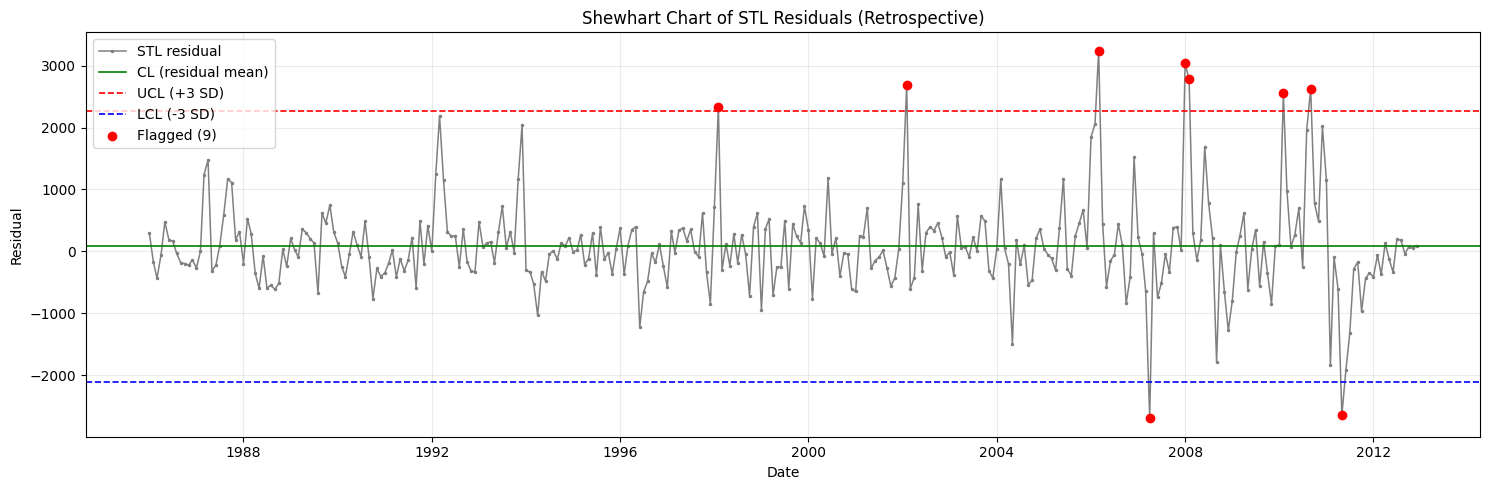

In [2]:
from io import StringIO

# ----------------------------
# 2. 데이터 정리 및 월별 주기 검사
# ----------------------------
df = pd.read_csv(StringIO(raw_data), skipinitialspace=True)
df['Date'] = pd.to_datetime(df['Date'], errors='raise')
df['Total'] = pd.to_numeric(df['Total'], errors='raise')
df = df.sort_values('Date').set_index('Date')

# 누락된 달을 임의 보간하지 않고 오류를 명시합니다.
if df.index.has_duplicates:
    raise ValueError('Duplicate monthly dates exist.')
expected_months = pd.date_range(df.index.min(), df.index.max(), freq='MS')
if not df.index.equals(expected_months):
    missing = expected_months.difference(df.index)
    raise ValueError(f'Monthly sequence is not continuous; missing={list(missing[:10])}')
if len(df) < 24:
    raise ValueError('At least two annual cycles are recommended for STL(period=12).')

# ----------------------------
# 3. STL 분해: 원본의 seasonal_decompose가 아니라 실제 STL 사용
# ----------------------------
# robust=True: 극단값이 추세·계절 성분에 미치는 영향을 완화합니다.
# 전체 기간을 사용하므로 이는 사후적 분해이지 미래 시점 온라인 탐지가 아닙니다.
stl_result = STL(df['Total'], period=12, robust=True).fit()
resid = stl_result.resid.dropna()

# ----------------------------
# 4. Shewhart 3-sigma 관리한계 (설명용 고정 한계)
# ----------------------------
# CL: 잔차 평균 / s: 표본 표준편차(ddof=1)
# UCL = CL + 3s, LCL = CL - 3s
# 주의: 실제 공정관리에서 관리한계를 설계하는 것과 동일시하지 않습니다.
cl = float(resid.mean())
s = float(resid.std(ddof=1))
ucl, lcl = cl + 3 * s, cl - 3 * s

# 잔차가 관리한계 바깥에 있는 관측치를 이상치 '후보'로 표시합니다.
flag = (resid > ucl) | (resid < lcl)
anomalies = pd.DataFrame({
    'Total': df.loc[resid.index, 'Total'],
    'Trend': stl_result.trend.loc[resid.index],
    'Seasonal': stl_result.seasonal.loc[resid.index],
    'Residual': resid,
    'Direction': np.where(resid > ucl, 'Above UCL',
                          np.where(resid < lcl, 'Below LCL', 'Within limits')),
}).loc[flag]

print(f'Data: {df.index.min():%Y-%m} to {df.index.max():%Y-%m}; N={len(df)}')
print(f'Shewhart residual limits: CL={cl:,.2f}, UCL={ucl:,.2f}, LCL={lcl:,.2f}')
print(f'Flagged: {len(anomalies)} / {len(resid)} ({100*flag.mean():.2f}%)')
print('Flagged observations (candidate anomalies):')
print(anomalies.round(2).to_string() if len(anomalies) else 'None')

# ----------------------------
# 5. 잔차 Shewhart 관리도
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 5), facecolor='white')
ax.set_facecolor('white')
ax.plot(resid.index, resid, color='gray', linewidth=1.1, marker='.',
        markersize=3, label='STL residual')
ax.axhline(cl, color='green', linewidth=1.2, label='CL (residual mean)')
ax.axhline(ucl, color='red', linestyle='--', linewidth=1.2, label='UCL (+3 SD)')
ax.axhline(lcl, color='blue', linestyle='--', linewidth=1.2, label='LCL (-3 SD)')
ax.scatter(resid.index[flag], resid.loc[flag], color='red', s=36,
           zorder=5, label=f'Flagged ({flag.sum()})')
ax.set(title='Shewhart Chart of STL Residuals (Retrospective)',
       xlabel='Date', ylabel='Residual')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
plt.tight_layout()
plt.show()


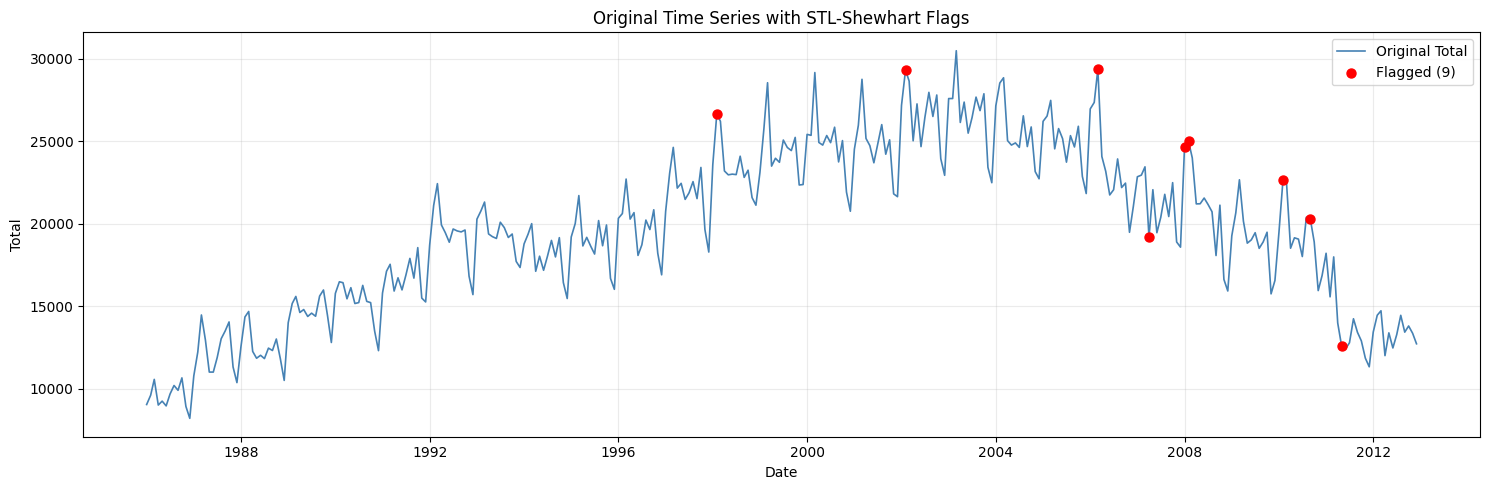

In [3]:
# ----------------------------
# 6. 원 시계열에서 동일한 이상치 '후보' 날짜 표시
# ----------------------------
# 관리한계는 원래 관측값이 아닌 STL 잔차에 적용됩니다.
# 빨간 점은 해당 날짜의 원래 관측값을 가리킵니다.
fig, ax = plt.subplots(figsize=(15, 5), facecolor='white')
ax.set_facecolor('white')
ax.plot(df.index, df['Total'], color='steelblue', linewidth=1.2, label='Original Total')
if len(anomalies):
    ax.scatter(anomalies.index, anomalies['Total'], s=42,
               color='red', zorder=5, label=f'Flagged ({len(anomalies)})')
ax.set(title='Original Time Series with STL-Shewhart Flags',
       xlabel='Date', ylabel='Total')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# 참고: 이상치 후보는 통계적 신호이며, 실제 오류나 특이 사건의 확정 증거가 아닙니다.
# 실제 해석에는 해당 날짜의 외부 사건, 계절조정 적합성, 잔차 자기상관 검토가 필요합니다.
